## Theory 
1. Can we use Bagging for regression problems 

--> Yes.

Bagging works for both classification and regression.

For regression → predictions are averaged

Example: Bagging Regressor

2. What is the difference between multiple model training and single model  training 

-->Single model: One model trained on full dataset → high variance risk

Multiple models (Ensemble): Many models trained on different subsets → 

combined prediction → better generalization

3. Explain the concept of feature randomness in Random Forest 

-->At each split:

Random subset of features is selected

Best split is chosen only from that subset

This reduces correlation between trees, improving diversity.

4. What is OOB (Out-of-Bag) Score 

--> In bootstrap sampling, ~63% data is used, ~37% left out

Left-out data = OOB samples

Used as validation set

OOB score ≈ cross-validation score (without extra data split)

5. How can you measure the importance of features in a Random Forest model

--> Methods:

Mean Decrease in Impurity (MDI)

Permutation Importance (shuffle feature → measure accuracy drop)

6. Explain the working principle of a Bagging Classifier 

--> Steps:

Create multiple bootstrap samples

Train one model per sample

Combine predictions using majority voting

7. How do you evaluate a Bagging Classifier’s performance 

--> Accuracy

Precision, Recall, F1-score

ROC-AUC

OOB score

Confusion Matrix

8. How does a Bagging Regressor work 

-->Same as classifier but:

Final output = average of predictions

9. What is the main advantage of ensemble techniques 

--> mproves accuracy and stability

Reduces variance

Reduces overfitting

10. What is the main challenge of ensemble methods 

--> High computational cost

Less interpretability

Longer training time

11. Explain the key idea behind ensemble techniques 

--> “Wisdom of the crowd”
Combine weak/medium models → strong model

12. What is a Random Forest Classifier 

--> Random Forest Classifier

Collection of decision trees

Uses bagging + feature randomness

Output via majority voting

13. What are the main types of ensemble techniques 

--> Bagging

Boosting

Stacking

14. What is ensemble learning in machine learning 
 
--> Technique of combining multiple models to improve performance

Produces more robust predictions than a single model

15. When should we avoid using ensemble methods 

--> Small datasets

Need for high interpretability

Limited computational resources

16. How does Bagging help in reducing overfitting 

--> Trains models on different subsets

Reduces variance by averaging

Prevents model from memorizing noise

17. Why is Random Forest better than a single Decision Tree 

--> Less overfitting

Better generalization

More stable predictions

Handles noise better

18. What is the role of bootstrap sampling in Bagging 

--> Creates multiple training datasets

Introduces diversity

Core mechanism behind Bagging

19. What are some real-world applications of ensemble techniques 

--> Fraud detection

Medical diagnosis

Recommendation systems

Stock prediction

Image classification

20. What is the difference between Bagging and Boosting? 

| Feature  | Bagging            | Boosting                    |

| -------- | ------------------ | --------------------------- |

| Goal     | Reduce variance    | Reduce bias + variance      |

| Training | Parallel           | Sequential                  |

| Data     | Random sampling    | Weighted sampling           |

| Focus    | Independent models | Correct previous errors     |

| Example  | Random Forest      | AdaBoost, Gradient Boosting |




## Practical 

In [13]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer, load_diabetes, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, mean_squared_error, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve)

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor, RandomForestClassifier, RandomForestRegressor, StackingClassifier,VotingClassifier,VotingRegressor
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy 


In [7]:
x,y = make_classification(n_samples=1000,n_features=20,n_informative=10,n_redundant=10,n_clusters_per_class=1,random_state=1) 

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [11]:
x_train.shape,x_test.shape

((800, 20), (200, 20))

In [14]:
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag_clf.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [16]:
y_pred = bag_clf.predict(x_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.925


22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE) 


In [19]:
x,y = make_regression(n_samples=1000,n_features=20,n_informative=10,random_state=1) 

In [20]:
bag_reg = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50)
bag_reg.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeRegressor()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [21]:
y_pred = bag_clf.predict(x_test)

In [22]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 0.075


23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores 

In [78]:
from sklearn.datasets import load_breast_cancer
x,y = load_breast_cancer(return_X_y=True)

In [79]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.25,random_state=1)

In [80]:
rf = RandomForestClassifier(n_estimators=100,oob_score=True,random_state=1)
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [81]:
imp = rf.feature_importances_
print("Feature Importances:", imp)

Feature Importances: [0.0671246  0.01598818 0.071876   0.04711783 0.00544168 0.00711463
 0.06070906 0.08454692 0.00436886 0.00294294 0.01948678 0.00294829
 0.00561975 0.02443827 0.00366473 0.00339149 0.00298649 0.00573809
 0.00293949 0.00541254 0.1031477  0.02169166 0.12827255 0.10979245
 0.01043704 0.01336977 0.02891715 0.12554284 0.00898419 0.005988  ]



24. Train a Random Forest Regressor and compare its performance with a single Decision Tree

In [37]:
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

In [38]:
model_tree = dt.fit(x_train,y_train)


In [39]:
model_forest = rf.fit(x_train, y_train)

In [40]:
y_pred_tree = model_tree.predict(x_test)
y_pred_forest = model_forest.predict(x_test)

In [44]:
print("mse Tree: ", mean_squared_error(y_test, y_pred_tree)) 
print("mse Forest: ",mean_squared_error(y_test, y_pred_forest))

mse Tree:  0.095
mse Forest:  0.05785449999999999



25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier 


In [82]:
print("OOB Score:", rf.oob_score_)

OOB Score: 0.9553990610328639



26. Train a Bagging Classifier using SVM as a base estimator and print accuracy 


In [50]:
bag_clf = BaggingClassifier(estimator=SVC(probability=True), n_estimators=100)
bag_clf.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC(probability=True)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [54]:
print("Accuracy:", accuracy_score(y_test, bag_clf.predict(x_test)))

Accuracy: 0.935


27. Train a Random Forest Classifier with different numbers of trees and compare accuracy 


In [57]:
for n in [10, 50, 100]:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(x_train, y_train)
    print(f"{n} trees accuracy:", accuracy_score(y_test, rf.predict(x_test)))

10 trees accuracy: 0.915
50 trees accuracy: 0.94
100 trees accuracy: 0.935


28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score 

In [60]:
bag_lr = BaggingClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=20)
bag_lr.fit(x_train, y_train)

y_prob = bag_lr.predict_proba(x_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.9415941594159416



29. Train a Random Forest Regressor and analyze feature importance scores 

In [83]:
rf_reg = RandomForestRegressor()
rf_reg.fit(x_train, y_train)

print("Feature Importance:", rf_reg.feature_importances_)

Feature Importance: [0.02498195 0.03841816 0.01108864 0.11727149 0.04577226 0.01965765
 0.02341439 0.01953989 0.02976509 0.02695638 0.03604427 0.26264682
 0.01089658 0.02401809 0.08741325 0.01332154 0.01998567 0.01500887
 0.01547686 0.15832215]



30. Train an ensemble model using both Bagging and Random Forest and compare accuracy. 

In [84]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier())
rf = RandomForestClassifier()

bag.fit(X_train, Y_train)
rf.fit(X_train, Y_train)

print("Bagging:", accuracy_score(Y_test, bag.predict(X_test)))
print("RF:", accuracy_score(Y_test, rf.predict(X_test)))

Bagging: 0.951048951048951
RF: 0.958041958041958



31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV 

In [85]:
param_grid = {"n_estimators": [50,100], "max_depth": [5,10,None]}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3,verbose=5)
grid.fit(X_train, Y_train)

print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END ......max_depth=5, n_estimators=50;, score=0.937 total time=   0.0s
[CV 2/3] END ......max_depth=5, n_estimators=50;, score=0.951 total time=   0.0s
[CV 3/3] END ......max_depth=5, n_estimators=50;, score=0.958 total time=   0.0s
[CV 1/3] END .....max_depth=5, n_estimators=100;, score=0.937 total time=   0.1s
[CV 2/3] END .....max_depth=5, n_estimators=100;, score=0.958 total time=   0.0s
[CV 3/3] END .....max_depth=5, n_estimators=100;, score=0.972 total time=   0.0s
[CV 1/3] END .....max_depth=10, n_estimators=50;, score=0.944 total time=   0.0s
[CV 2/3] END .....max_depth=10, n_estimators=50;, score=0.965 total time=   0.0s
[CV 3/3] END .....max_depth=10, n_estimators=50;, score=0.958 total time=   0.0s
[CV 1/3] END ....max_depth=10, n_estimators=100;, score=0.923 total time=   0.0s
[CV 2/3] END ....max_depth=10, n_estimators=100;, score=0.951 total time=   0.0s
[CV 3/3] END ....max_depth=10, n_estimators=100;,


32. Train a Bagging Regressor with different numbers of base estimators and compare performance 

In [65]:
for n in [10, 50, 100]:
    bag = BaggingRegressor(n_estimators=n)
    bag.fit(x_train, y_train)
    print(n, "MSE:", mean_squared_error(y_test, bag.predict(x_test)))

10 MSE: 0.0679
50 MSE: 0.063678
100 MSE: 0.060124000000000004



33. Train a Random Forest Classifier and analyze misclassified samples 

In [66]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
misclassified = np.where(y_test != y_pred)[0]
print("Misclassified indices:", misclassified[:10])

Misclassified indices: [  6  24  49  59  89 104 106 115 122 129]



34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier 

In [86]:
dt = DecisionTreeClassifier()
bag = BaggingClassifier(estimator=DecisionTreeClassifier())

dt.fit(X_train, Y_train)
bag.fit(X_train, Y_train)

print("DT:", accuracy_score(Y_test, dt.predict(X_test)))
print("Bagging:", accuracy_score(Y_test, bag.predict(X_test)))

DT: 0.9370629370629371
Bagging: 0.965034965034965



35. Train a Random Forest Classifier and visualize the confusion matrix 

In [89]:
cm = confusion_matrix(Y_test, rf.predict(X_test))
print(cm)

[[50  5]
 [ 1 87]]



36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy 

In [90]:
estimators = [
    ("dt", DecisionTreeClassifier()),
    ("svm", SVC(probability=True)),
    ("lr", LogisticRegression(max_iter=1000))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, Y_train)

print("Stack Accuracy:", accuracy_score(Y_test, stack.predict(X_test)))

Stack Accuracy: 0.951048951048951



37. Train a Random Forest Classifier and print the top 5 most important features 

In [91]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-5:]
print("Top 5 features:", indices)

Top 5 features: [ 6 27 23 20 22]



38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score 

In [93]:
y_pred = bag.predict(X_test)

print("Precision:", precision_score(Y_test, rf.predict(X_test)))
print("Recall:", recall_score(Y_test, rf.predict(X_test)))
print("F1:", f1_score(Y_test, rf.predict(X_test)))

Precision: 0.9456521739130435
Recall: 0.9886363636363636
F1: 0.9666666666666667



39. Train a Random Forest Classifier and analyze the effect of max_depth on accuracy 

In [94]:
for d in [3,5,10,None]:
    rf = RandomForestClassifier(max_depth=d)
    rf.fit(X_train, Y_train)
    print(d, accuracy_score(Y_test, rf.predict(X_test)))

3 0.951048951048951
5 0.951048951048951
10 0.965034965034965
None 0.958041958041958



40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance 

In [96]:
bag_dt = BaggingRegressor(estimator=DecisionTreeRegressor())
bag_knn = BaggingRegressor(estimator=KNeighborsRegressor())

bag_dt.fit(X_train, Y_train)
bag_knn.fit(X_train, Y_train)

print("DT MSE:", mean_squared_error(Y_test, bag_dt.predict(X_test)))
print("KNN MSE:", mean_squared_error(Y_test, bag_knn.predict(X_test)))

DT MSE: 0.04188811188811189
KNN MSE: 0.05968111888111888



41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score 

In [97]:
rf = RandomForestClassifier()
rf.fit(X_train, Y_train)

y_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(Y_test, y_prob))

ROC-AUC: 0.9800619834710744



42. Train a Bagging Classifier and evaluate its performance using cross-validation 

In [101]:
scores = cross_val_score(bag, x, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.943797546964757



43. Train a Random Forest Classifier and plot the Precision-Recall curve 

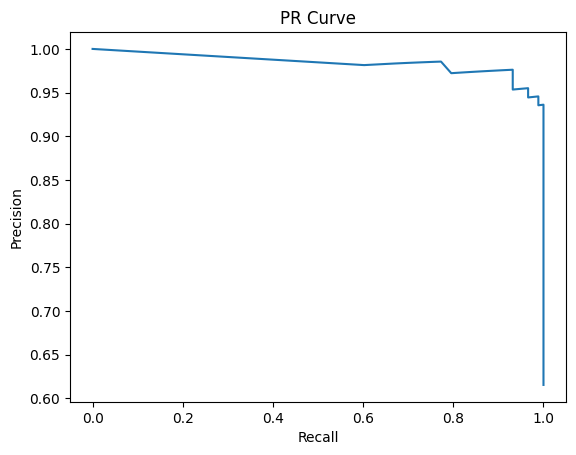

In [98]:
y_prob = rf.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(Y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()


44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy

In [102]:
estimators = [
    ("rf", RandomForestClassifier()),
    ("lr", LogisticRegression(max_iter=1000))
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, Y_train)

print("Stack Accuracy:", accuracy_score(Y_test, stack.predict(X_test)))

Stack Accuracy: 0.965034965034965


 
45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [103]:
for b in [True, False]:
    bag = BaggingRegressor(bootstrap=b)
    bag.fit(X_train, Y_train)
    print("Bootstrap:", b, "MSE:", mean_squared_error(Y_test, bag.predict(X_test)))

Bootstrap: True MSE: 0.04426573426573427
Bootstrap: False MSE: 0.03426573426573427
